# Proyecto Final — Predicción de Recepción Crítica en Rotten Tomatoes

### Alumno: Ariel German Marin

## Abstracto con Motivación y Audiencia

La industria cinematográfica invierte sumas considerables en la producción
y promoción de películas, y la recepción crítica es uno de los factores
que más influye en el éxito comercial de un estreno. Este proyecto busca
predecir, a partir de información disponible antes del estreno, si una
película será clasificada como "Rotten", "Fresh" o "Certified-Fresh"
según el Tomatometer de Rotten Tomatoes.

El análisis está dirigido a estudios cinematográficos, distribuidoras y
equipos de marketing que necesitan anticipar la recepción crítica
esperada de un título, para así tomar decisiones informadas sobre
presupuesto de promoción, cantidad de salas de estreno o fecha de
lanzamiento más conveniente.

## Contexto Comercial y Analítico

Rotten Tomatoes es una de las plataformas de referencia en la industria
del entretenimiento para medir la recepción crítica de una película,
a través del Tomatometer: un puntaje que resume el porcentaje de
reseñas de críticos certificados que calificaron la película de forma
positiva, y la clasifica en tres categorías: Rotten, Fresh y
Certified-Fresh.

Desde el punto de vista analítico, este es un problema de clasificación
multiclase, donde el desafío principal es identificar qué atributos de
una película (género, clasificación por edad, elenco, dirección,
duración, estudio productor, fecha de estreno) están asociados a una
mejor o peor recepción crítica, utilizando únicamente información
disponible antes de que la película llegue a cartelera.

## Preguntas/Hipótesis a Resolver mediante el Análisis de Datos

- ¿El género principal de una película influye en su recepción crítica?
- ¿La clasificación por edad (content rating) está asociada a mejor o
  peor Tomatometer?
- ¿El efecto de la clasificación por edad varía según el género
  (interacción entre ambas variables)?
- ¿La duración de la película (runtime) se relaciona con su
  clasificación crítica?
- ¿El año/década de estreno influye en la recepción crítica, y en qué
  medida ese efecto refleja un sesgo de los datos disponibles más que
  una tendencia real?
- ¿La cantidad de géneros asociados a una película, o la cantidad de
  actores en el elenco, aportan información relevante?

## Objetivo

Construir un modelo de clasificación multiclase que permita predecir si
una película será calificada como "Rotten", "Fresh" o "Certified-Fresh"
en Rotten Tomatoes, utilizando exclusivamente variables disponibles
antes del estreno (género, clasificación por edad, dirección, guion,
elenco, duración, estudio productor y fecha de estreno).

La métrica de éxito principal será el F1 macro, dado el desbalance
moderado entre clases (43% Rotten, 37% Fresh, 19% Certified-Fresh), y
se complementará con el AUC one-vs-rest. El modelo final se
seleccionará comparando distintos algoritmos (regresión logística,
árbol de decisión, Random Forest y XGBoost), optimizando
hiperparámetros con GridSearchCV/RandomizedSearchCV, y su
interpretabilidad se evaluará mediante SHAP.

## Fuente de los datos

Los datos fueron obtenidos del dataset "Rotten Tomatoes Movies and
Critic Reviews" publicado en Kaggle, scrapeado del
sitio público rottentomatoes.com con corte al 31/10/2020. El dataset
contiene dos tablas: `movies` (una fila por película, con metadata y
puntajes) y `critics` (una fila por reseña individual de crítico). Para
este proyecto se trabaja principalmente sobre la tabla `movies`, y se
excluyen explícitamente las columnas que representan información
posterior al estreno (tomatometer_rating, tomatometer_count,
audience_rating, audience_count, entre otras), para evitar leakage.

## Cómo vamos a dividir y realizar el trabajo

El desarrollo se organiza siguiendo el orden que exige la consigna:

1. **Lectura de datos:** carga del dataset, análisis inicial de
   estructura y descripción de variables.
2. **Data Wrangling:** tratamiento de duplicados, valores nulos
   (con estrategia justificada por columna) y outliers.
3. **Análisis Exploratorio de Datos (EDA):** análisis univariado,
   bivariado y multivariado de las variables frente al target,
   con conclusiones documentadas en cada etapa.
4. **Feature Engineering:** creación de nuevas variables (encoding de
   géneros múltiples, agrupación de categorías de alta cardinalidad,
   extracción de componentes de fecha) y selección final de variables
   independientes.
5. **Preprocesamiento:** codificación de variables categóricas y
   preparación del dataset para el modelado, dentro de un Pipeline
   para evitar fugas de información entre entrenamiento y validación.
6. **Modelado:** entrenamiento y comparación de distintos algoritmos
   de clasificación, con división estratificada en conjuntos de
   entrenamiento y prueba.
7. **Optimización:** ajuste de hiperparámetros del modelo con mejor
   desempeño mediante GridSearchCV/RandomizedSearchCV con validación
   cruzada estratificada.
8. **Explicabilidad:** interpretación del modelo final con SHAP,
   identificando qué variables más influyen en la predicción.
9. **Conclusiones finales:** síntesis de resultados, limitaciones del
   enfoque y posibles líneas de mejora.

## Lectura de datos

Se cargan las dos tablas que componen el dataset: `movies`, con una
fila por película y su metadata (género, director, elenco, fechas,
puntajes), y `critics`, con una fila por reseña individual de crítico.
Se realiza un análisis inicial de ambas para conocer su estructura,
tipos de datos, y distribución de las variables más relevantes antes
de definir qué columnas se utilizarán para el modelo.

In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.dummy import DummyClassifier


In [286]:
critics = pd.read_csv("../data/raw/critics.csv")
movies = pd.read_csv("../data/raw/movies.csv")

### Análisis inicial del dataset

In [287]:
movies.head()

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2015-11-25,119.0,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2012-09-04,90.0,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,2014-07-24,122.0,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,2017-01-13,95.0,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,2016-06-10,127.0,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


In [288]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 17712 entries, 0 to 17711
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rotten_tomatoes_link              17712 non-null  str    
 1   movie_title                       17712 non-null  str    
 2   movie_info                        17391 non-null  str    
 3   critics_consensus                 9134 non-null   str    
 4   content_rating                    17712 non-null  str    
 5   genres                            17693 non-null  str    
 6   directors                         17518 non-null  str    
 7   authors                           16170 non-null  str    
 8   actors                            17360 non-null  str    
 9   original_release_date             16546 non-null  str    
 10  streaming_release_date            17328 non-null  str    
 11  runtime                           17398 non-null  float64
 12  production_comp

In [289]:
movies.describe(include = object)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19332\3622578982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  movies.describe(include = object)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,production_company,tomatometer_status,audience_status
count,17712,17712,17391,9134,17712,17693,17518,16170,17360,16546,17328,17213,17668,17264
unique,17712,17106,17389,9132,6,1106,8933,12989,17330,5804,2271,3046,3,2
top,m/0814255,Hamlet,"Wisecracking mercenary Deadpool meets Russell,...",High Life is as visually arresting as it is ch...,R,Drama,Clint Eastwood,Woody Allen,Chris Rock,2002-01-01,2016-08-10,Paramount Pictures,Rotten,Upright
freq,1,6,2,2,6377,1887,38,33,4,29,1235,517,7565,9390


In [290]:
columnas_relevantes= ["content_rating","tomatometer_status","audience_status"]

def valores_de_columnas (df) :
    for columna in columnas_relevantes:
        print(f"Columna: {columna}\n")
        print(f"{df[columna].value_counts(normalize = True).mul(100).round(2)}\n")


In [291]:
valores_de_columnas (movies)

Columna: content_rating

content_rating
R        36.00
NR       30.91
PG-13    16.82
PG       12.24
G         3.82
NC17      0.21
Name: proportion, dtype: float64

Columna: tomatometer_status

tomatometer_status
Rotten             42.82
Fresh              38.74
Certified-Fresh    18.45
Name: proportion, dtype: float64

Columna: audience_status

audience_status
Upright    54.39
Spilled    45.61
Name: proportion, dtype: float64



In [292]:
movies.describe()

,runtime,tomatometer_rating,tomatometer_count,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
count,17398.000000,17668.000000,17668.000000,17416.000000,1.741500e+04,17712.000000,17712.000000,17712.000000
mean,102.214048,60.884763,57.139801,60.554260,1.439401e+05,14.586326,36.374831,20.703139
std,18.702511,28.443348,68.370047,20.543369,1.763577e+06,15.146349,52.601038,30.248435
min,5.000000,0.000000,5.000000,0.000000,5.000000e+00,0.000000,0.000000,0.000000
25%,90.000000,38.000000,12.000000,45.000000,7.075000e+02,3.000000,6.000000,3.000000
50%,99.000000,67.000000,28.000000,63.000000,4.277000e+03,8.000000,16.000000,8.000000
75%,111.000000,86.000000,75.000000,78.000000,2.498800e+04,23.000000,44.000000,24.000000
max,266.000000,100.000000,574.000000,100.000000,3.579764e+07,69.000000,497.000000,303.000000


In [293]:
critics.head()

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...


In [294]:
critics.info()

<class 'pandas.DataFrame'>
RangeIndex: 1130017 entries, 0 to 1130016
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   rotten_tomatoes_link  1130017 non-null  str  
 1   critic_name           1111488 non-null  str  
 2   top_critic            1130017 non-null  bool 
 3   publisher_name        1130017 non-null  str  
 4   review_type           1130017 non-null  str  
 5   review_score          824081 non-null   str  
 6   review_date           1130017 non-null  str  
 7   review_content        1064211 non-null  str  
dtypes: bool(1), str(7)
memory usage: 61.4 MB


In [295]:
critics.describe(include=object)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19332\3553015986.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  critics.describe(include=object)


,rotten_tomatoes_link,critic_name,publisher_name,review_type,review_score,review_date,review_content
count,1130017,1111488,1130017,1130017,824081,1130017,1064211
unique,17712,11108,2230,2,814,8015,949181
top,m/star_wars_the_rise_of_skywalker,Emanuel Levy,New York Times,Fresh,3/5,2000-01-01,Parental Content Review
freq,992,8173,13293,720210,90273,48019,267


In [296]:
critics["review_type"].value_counts(normalize=True).mul(100).round(2)

review_type
Fresh     63.73
Rotten    36.27
Name: proportion, dtype: float64

### Selección de variables

A partir de la descripción anterior, se separan las columnas en tres
grupos: las que se usarán como variable objetivo y features del modelo
(información previa al estreno), las que se reservan solo para el EDA
exploratorio (incluyen información posterior al estreno, útil para
entender el dataset pero no para predecir), y las que se descartan por
representar directamente el resultado que se busca predecir (leakage).

In [297]:
target_y_features = ["rotten_tomatoes_link",'tomatometer_status', 'content_rating', 'genres', 'directors',
                      'authors', 'actors', 'original_release_date', 'runtime', 'production_company']

solo_eda = ['movie_title', 'movie_info', 'critics_consensus','streaming_release_date']

descartadas = ['tomatometer_rating', 'tomatometer_count', 'tomatometer_top_critics_count',
               'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count',
               'audience_status', 'audience_rating', 'audience_count']


## Data Wrangling - Limpieza y transformación de datos

Antes del análisis exploratorio, se depura `model_movies` (el
subconjunto de columnas elegido para el modelo): se verifican
duplicados, se trata cada valor nulo con una estrategia justificada
según el tipo de variable, se revisan outliers en las variables
numéricas y se aplican las transformaciones necesarias sobre fechas,
descartando las filas sin variable objetivo.

In [298]:
model_movies = movies[target_y_features].copy()

In [299]:
model_movies.head(5)

,rotten_tomatoes_link,tomatometer_status,content_rating,genres,directors,authors,actors,original_release_date,runtime,production_company
0,m/0814255,Rotten,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox
1,m/0878835,Certified-Fresh,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,90.0,Sony Pictures Classics
2,m/10,Fresh,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,122.0,Waner Bros.
3,m/1000013-12_angry_men,Certified-Fresh,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,95.0,Criterion Collection
4,m/1000079-20000_leagues_under_the_sea,Fresh,G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,127.0,Disney


### Descripción de variables

| Variable | Tipo | Descripción |
|---|---|---|
| tomatometer_status | categórica | Variable objetivo: Rotten / Fresh / Certified-Fresh |
| content_rating | categórica | Clasificación por edad |
| genres | texto (lista) | Géneros, separados por coma |
| directors | texto | Director(es) |
| authors | texto | Guionista(s) |
| actors | texto | Elenco principal |
| original_release_date | fecha | Fecha de estreno en cines |
| runtime | numérica | Duración en minutos |
| production_company | texto | Productora |

### Valores duplicados y nulos
Se verifica que no existan películas repetidas ni tanpoco valores nulos, usando
`rotten_tomatoes_link` como identificador único.

In [300]:
model_movies["rotten_tomatoes_link"].duplicated().sum()

np.int64(0)

In [301]:
model_movies["tomatometer_status"].isnull().sum()

np.int64(44)

### Transformacion de datos

In [302]:
model_movies["original_release_date"] = pd.to_datetime(
    model_movies["original_release_date"],
    format="%Y-%m-%d"
    )

In [303]:
model_movies["original_release_date"].isnull().sum()

np.int64(1166)

### Diagnostico de cada columna

### Valores nulos

Se calcula el porcentaje de nulos por columna y se decide, caso por
caso, la estrategia de tratamiento: eliminar filas cuando el impacto
es insignificante, imputar con una medida central en variables
numéricas, o asignar una categoría explícita ("Unknown") en variables
categóricas de alta cardinalidad, para no perder datos
innecesariamente.

In [304]:
def diagnostico (df):

    resumen = pd.DataFrame({
        "dtype" : df.dtypes,
        "nulos" : df.isnull().sum(),
        "% nulos" : (df.isnull().sum() / len(df)).mul(100).round(2),
        "ceros" : df.eq(0).sum(),
        "unicos" : df.nunique(),
        "% unicos" : (df.nunique() / len(df)).mul(100).round(2) 
    }).sort_values("% nulos", ascending = False)

    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
    return resumen

In [305]:
diagnostico(model_movies)


Filas: 17,712 | Columnas: 10


,dtype,nulos,% nulos,ceros,unicos,% unicos
authors,str,1542,8.71,0,12989,73.33
original_release_date,datetime64[us],1166,6.58,0,5804,32.77
production_company,str,499,2.82,0,3046,17.20
actors,str,352,1.99,0,17330,97.84
runtime,float64,314,1.77,0,190,1.07
directors,str,194,1.10,0,8933,50.43
tomatometer_status,str,44,0.25,0,3,0.02
genres,str,19,0.11,0,1106,6.24
rotten_tomatoes_link,str,0,0.00,0,17712,100.00
content_rating,str,0,0.00,0,6,0.03


In [306]:
#El porcentaje es insignificante, no vale la pena inventar
# un valor. Dropear estas filas no afecta la representatividad del dataset.

model_movies = model_movies.dropna(subset=["genres"])

In [307]:
# limpiar formato
# (espacios, mayúsculas) para que no se cuenten como categorías distintas.
model_movies["content_rating"] = model_movies["content_rating"].str.strip()
print(model_movies["content_rating"].value_counts())

content_rating
R        6373
NR       5463
PG-13    2976
PG       2167
G         676
NC17       38
Name: count, dtype: int64


In [308]:
# es numérica y el % es bajo. Usamos la MEDIANA en vez del
# promedio porque la duración de películas suele tener outliers hacia
# arriba (películas muy largas), y la mediana no se deja arrastrar por eso.
# Guardamos un flag para no perder el rastro de qué filas fueron imputadas,
# por si después querés evaluar si eso afecta al modelo.
model_movies["runtime_was_missing"] = model_movies["runtime"].isna().astype(int)
mediana_runtime = model_movies["runtime"].median()
model_movies["runtime"] = model_movies["runtime"].fillna(mediana_runtime)
print(f"Mediana usada para imputar runtime: {mediana_runtime} min")

Mediana usada para imputar runtime: 99.0 min


In [309]:
pd.crosstab(model_movies["runtime_was_missing"], model_movies["tomatometer_status"], normalize="index").round(3)

tomatometer_status,Certified-Fresh,Fresh,Rotten
runtime_was_missing,,,
0,0.186,0.383,0.431
1,0.092,0.655,0.254


In [310]:
# "no tiene director registrado" es información en sí misma
# (puede tratarse de documentales, producciones colectivas, o datos
# faltantes del scraping). Preferimos conservar la fila con una categoría
# explícita antes que perder datos.
model_movies["directors"] = model_movies["directors"].fillna("Unknown")

In [311]:
# Misma lógica que directors.
model_movies["actors"] = model_movies["actors"].fillna("Unknown")

In [312]:
# Misma lógica: la ausencia de productora registrada puede ser señal de
# producciones independientes o datos incompletos, así que lo marcamos
# explícitamente en vez de descartar la fila.
model_movies["production_company"] = model_movies["production_company"].fillna("Unknown")

In [313]:
# aunque el % es más alto que en las otras columnas de
# cast/crew, dropear implicaría perder ~9% del dataset. Como es
# categórica de alta cardinalidad, "Unknown" se integra como una
# categoría más sin distorsionar el modelo, igual que con directors/actors.
model_movies["authors"] = model_movies["authors"].fillna("Unknown")

### Verificación de valores outliers

`runtime` es la única variable numérica continua del dataset, por lo
que es la única donde este análisis aplica. Se utiliza el rango
intercuartílico (IQR) para identificar valores extremos, evaluando si
corresponden a datos inconsistentes o a casos legítimos (películas
muy cortas o muy largas).

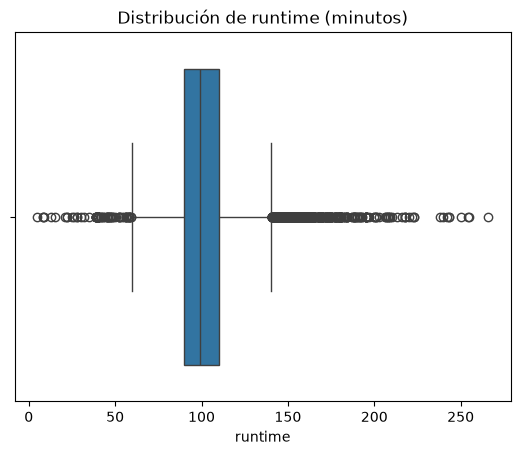

count    17693.000000
mean       102.162946
std         18.539146
min          5.000000
25%         90.000000
50%         99.000000
75%        110.000000
max        266.000000
Name: runtime, dtype: float64
Límites IQR: 60 - 140 min | Outliers: 689


In [314]:
sns.boxplot(x=model_movies["runtime"])
plt.title("Distribución de runtime (minutos)")
plt.show()

print(model_movies["runtime"].describe())

Q1, Q3 = model_movies["runtime"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = model_movies[(model_movies["runtime"] < lim_inf) | (model_movies["runtime"] > lim_sup)]
print(f"Límites IQR: {lim_inf:.0f} - {lim_sup:.0f} min | Outliers: {len(outliers)}")

### Conclusión: 
los valores se encuentran dentro de un rango numérico
válido (sin negativos, ceros ni datos corruptos). No se requieren
correcciones, ya que el objetivo del análisis exige solo consistencia de los
datos para el EDA y el modelado.

### Otras transformaciones, normalización, fechas

Se eliminan las filas sin fecha de estreno, ya que no es posible
imputar una fecha de forma honesta, y se descartan las filas sin
valor en la variable objetivo (`tomatometer_status`), dado que no
aportan ni al entrenamiento ni a la evaluación del modelo. Se
verifica el estado final del dataset antes de pasar al análisis
exploratorio.

In [315]:
# fecha

model_movies = model_movies.dropna(subset=["original_release_date"])


In [316]:
model_movies = model_movies.dropna(subset=["tomatometer_status"])

In [317]:
diagnostico(model_movies)


Filas: 16,507 | Columnas: 11


,dtype,nulos,% nulos,ceros,unicos,% unicos
rotten_tomatoes_link,str,0,0.0,0,16507,100.00
tomatometer_status,str,0,0.0,0,3,0.02
content_rating,str,0,0.0,0,6,0.04
genres,str,0,0.0,0,1069,6.48
directors,str,0,0.0,0,8253,50.00
authors,str,0,0.0,0,12213,73.99
actors,str,0,0.0,0,16228,98.31
original_release_date,datetime64[us],0,0.0,0,5796,35.11
runtime,float64,0,0.0,0,184,1.11
production_company,str,0,0.0,0,2798,16.95


## Análisis Exploratorio de datos

Se construye `model_eda`, un dataframe que suma a las variables del
modelo algunas columnas de solo-exploración (`movie_title`,
`movie_info`, `critics_consensus`, `streaming_release_date`), útiles
para enriquecer el análisis aunque no participen del entrenamiento.

In [318]:
model_eda = model_movies.copy()

In [319]:
model_eda = model_eda.merge(
    movies[['rotten_tomatoes_link'] + solo_eda],
    on='rotten_tomatoes_link',
    how='left'
)

print(model_eda.shape)
model_eda.info()

(16507, 15)
<class 'pandas.DataFrame'>
RangeIndex: 16507 entries, 0 to 16506
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   rotten_tomatoes_link    16507 non-null  str           
 1   tomatometer_status      16507 non-null  str           
 2   content_rating          16507 non-null  str           
 3   genres                  16507 non-null  str           
 4   directors               16507 non-null  str           
 5   authors                 16507 non-null  str           
 6   actors                  16507 non-null  str           
 7   original_release_date   16507 non-null  datetime64[us]
 8   runtime                 16507 non-null  float64       
 9   production_company      16507 non-null  str           
 10  runtime_was_missing     16507 non-null  int64         
 11  movie_title             16507 non-null  str           
 12  movie_info              16357 non-null  str  

In [320]:
model_eda["streaming_release_date"] = pd.to_datetime(model_eda["streaming_release_date"], errors="coerce")
print(model_eda["streaming_release_date"].dtype)

datetime64[us]


In [321]:
model_eda["dias_a_streaming"] = (model_eda["streaming_release_date"] - model_eda["original_release_date"]).dt.days
print(model_eda["dias_a_streaming"].describe())

count    16287.000000
mean      5842.035304
std       7013.540494
min      -1394.000000
25%        716.000000
50%       3235.000000
75%       8066.500000
max      37376.000000
Name: dias_a_streaming, dtype: float64


In [322]:
diagnostico(model_eda)


Filas: 16,507 | Columnas: 16


,dtype,nulos,% nulos,ceros,unicos,% unicos
critics_consensus,str,7623,46.18,0,8882,53.81
streaming_release_date,datetime64[us],220,1.33,0,2190,13.27
dias_a_streaming,float64,220,1.33,653,8823,53.45
movie_info,str,150,0.91,0,16356,99.09
rotten_tomatoes_link,str,0,0.00,0,16507,100.00
tomatometer_status,str,0,0.00,0,3,0.02
content_rating,str,0,0.00,0,6,0.04
genres,str,0,0.00,0,1069,6.48
original_release_date,datetime64[us],0,0.00,0,5796,35.11
actors,str,0,0.00,0,16228,98.31


### Análisis univariado

Se analiza la distribución individual de cada variable relevante,
comenzando por la variable objetivo.

tomatometer_status
Rotten             7154
Fresh              6158
Certified-Fresh    3195
Name: count, dtype: int64

% por clase:
tomatometer_status
Rotten             43.34
Fresh              37.31
Certified-Fresh    19.36
Name: proportion, dtype: float64


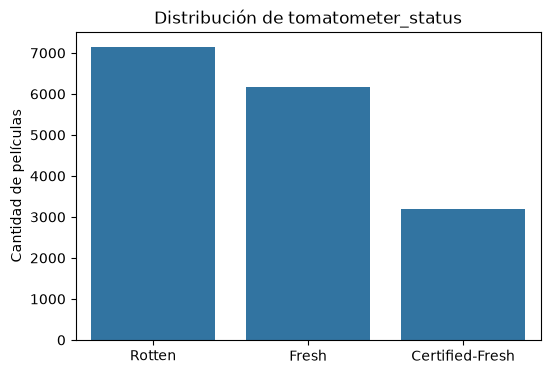

In [323]:
# ===== ANÁLISIS UNIVARIADO =====

# --- Variable objetivo: tomatometer_status ---
print(model_eda["tomatometer_status"].value_counts())
print("\n% por clase:")
print((model_eda["tomatometer_status"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=model_eda, x="tomatometer_status",
              order=model_eda["tomatometer_status"].value_counts().index)
plt.title("Distribución de tomatometer_status")
plt.xlabel("")
plt.ylabel("Cantidad de películas")
plt.show()

El target presenta un desbalance moderado: 43% Rotten, 37% Fresh y
19% Certified-Fresh. Esto descarta usar accuracy como métrica
principal; se utilizará F1 macro.

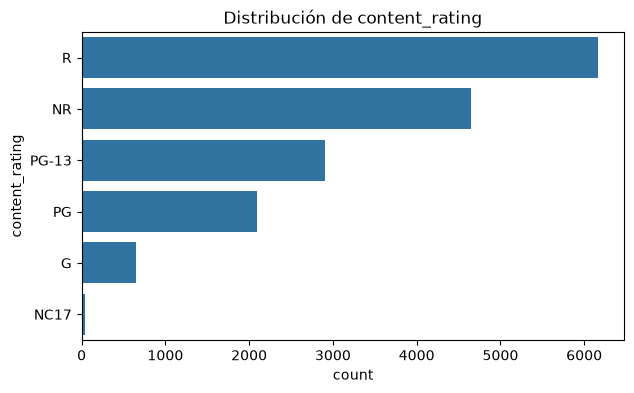

In [324]:
# --- content_rating ---
plt.figure(figsize=(7,4))
sns.countplot(data=model_eda, y="content_rating",
              order=model_eda["content_rating"].value_counts().index)
plt.title("Distribución de content_rating")
plt.show()

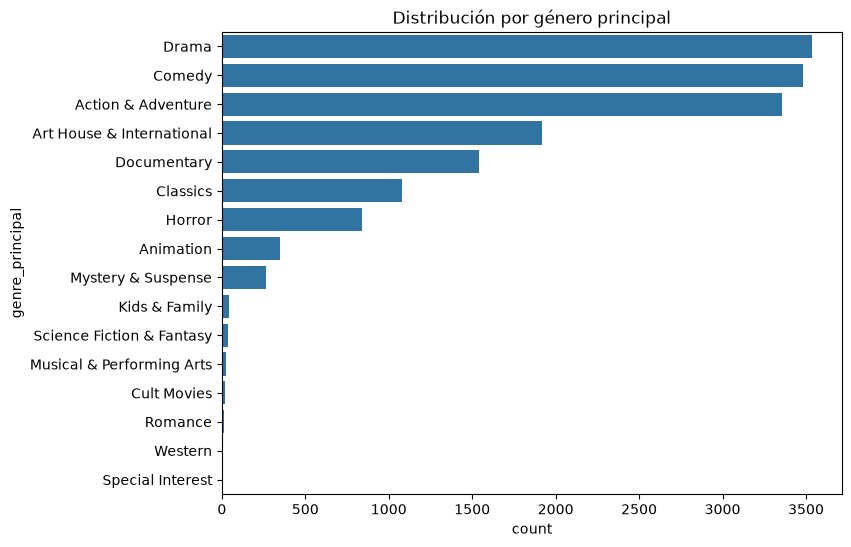

In [325]:
# --- genres: viene con varios géneros por película separados por coma,
# nos quedamos con el primero (el principal) para este análisis ---
model_eda["genre_principal"] = model_eda["genres"].str.split(",").str[0].str.strip()

plt.figure(figsize=(8,6))
sns.countplot(data=model_eda, y="genre_principal",
              order=model_eda["genre_principal"].value_counts().index)
plt.title("Distribución por género principal")
plt.show()

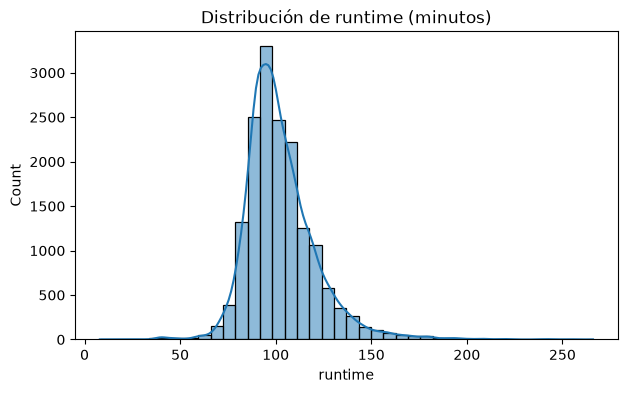

count    16507.000000
mean       102.632762
std         18.625805
min          8.000000
25%         91.000000
50%         99.000000
75%        111.000000
max        266.000000
Name: runtime, dtype: float64


In [326]:
# --- runtime ---
plt.figure(figsize=(7,4))
sns.histplot(model_eda["runtime"], bins=40, kde=True)
plt.title("Distribución de runtime (minutos)")
plt.show()

print(model_eda["runtime"].describe())

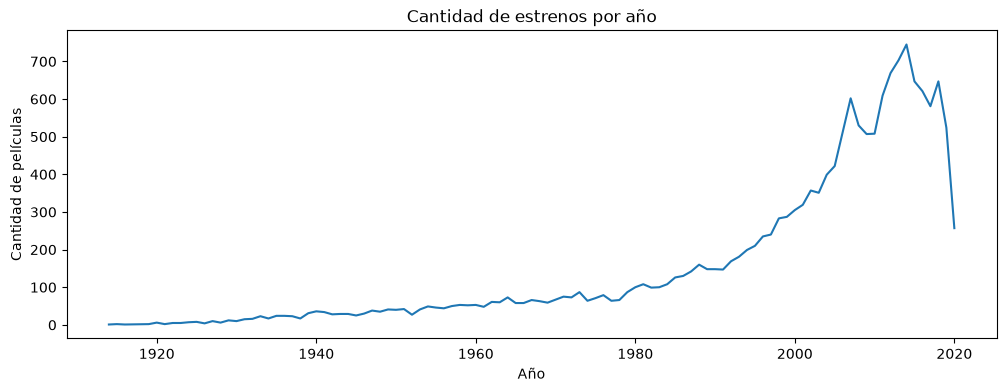

Año con más estrenos: 2014


In [327]:
# --- Estrenos a lo largo del tiempo ---
model_eda["release_year"] = model_eda["original_release_date"].dt.year

plt.figure(figsize=(12,4))
model_eda["release_year"].value_counts().sort_index().plot(kind="line")
plt.title("Cantidad de estrenos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.show()

print("Año con más estrenos:", model_eda["release_year"].value_counts().idxmax())

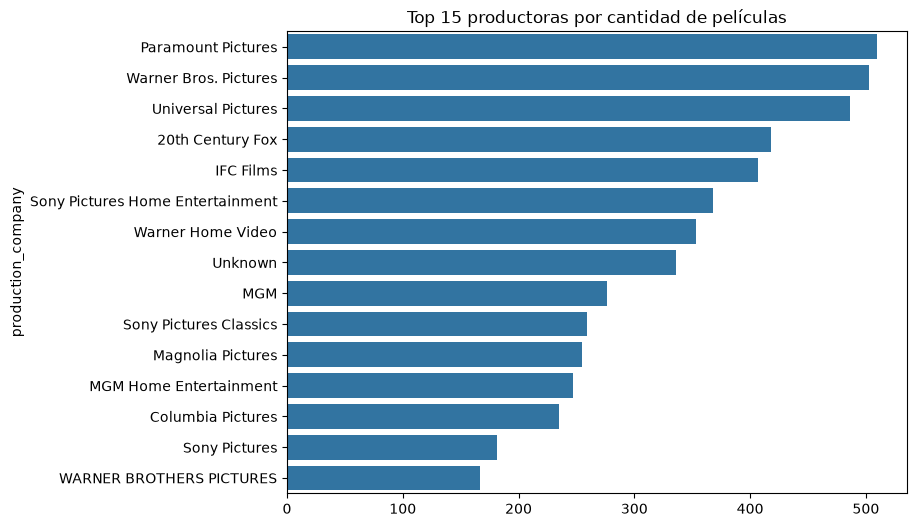

In [328]:
# --- production_company: top 15 ---
plt.figure(figsize=(8,6))
top_studios = model_eda["production_company"].value_counts().head(15)
sns.barplot(x=top_studios.values, y=top_studios.index)
plt.title("Top 15 productoras por cantidad de películas")
plt.show()

In [329]:
model_eda["production_company"] = model_eda["production_company"].str.strip().str.upper()

print(model_eda["production_company"].value_counts().head(20))

production_company
PARAMOUNT PICTURES                          510
WARNER BROS. PICTURES                       503
UNIVERSAL PICTURES                          486
20TH CENTURY FOX                            418
IFC FILMS                                   407
SONY PICTURES HOME ENTERTAINMENT            368
WARNER HOME VIDEO                           353
UNKNOWN                                     336
MGM                                         276
SONY PICTURES CLASSICS                      259
MAGNOLIA PICTURES                           255
MGM HOME ENTERTAINMENT                      247
COLUMBIA PICTURES                           235
SONY PICTURES                               181
WARNER BROTHERS PICTURES                    167
MIRAMAX                                     164
UNITED ARTISTS                              162
TWENTIETH CENTURY FOX HOME ENTERTAINMENT    157
MCA UNIVERSAL HOME VIDEO                    156
MIRAMAX FILMS                               156
Name: count, dtype: i

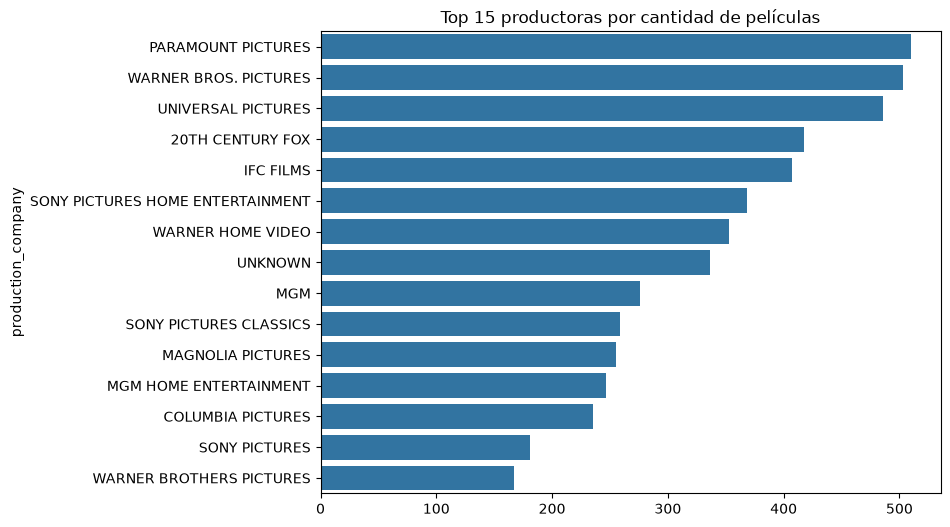

In [330]:
# --- production_company: top 15 ---
plt.figure(figsize=(8,6))
top_studios = model_eda["production_company"].value_counts().head(15)
sns.barplot(x=top_studios.values, y=top_studios.index)
plt.title("Top 15 productoras por cantidad de películas")
plt.show()

Se detectaron variantes de nombre para un mismo estudio (ej. "Warner
Bros. Pictures" / "Warner Home Video" / "Warner Brothers Pictures").
La normalización a mayúsculas unificó los casos que diferían solo en
formato; el resto se resolverá con un mapeo manual en la etapa de
Feature Engineering.

### Análisis bivariado

Se cruza cada variable contra `tomatometer_status` para identificar
cuáles muestran mayor poder discriminante antes de pasar al modelado.

In [331]:
# content_rating vs tomatometer_status
pd.crosstab(model_eda["content_rating"], model_eda["tomatometer_status"], normalize="index").round(3)

tomatometer_status,Certified-Fresh,Fresh,Rotten
content_rating,,,
G,0.205,0.511,0.284
NC17,0.222,0.500,0.278
NR,0.141,0.619,0.240
PG,0.201,0.351,0.448
PG-13,0.204,0.201,0.595
R,0.224,0.261,0.515


NR es la categoría más "Fresh-friendly" (62% Fresh). PG-13 y R son
las más castigadas (59% y 51% Rotten respectivamente).

In [332]:
# genre_principal (top 10) vs tomatometer_status
top_generos = model_eda["genre_principal"].value_counts().head(10).index
subset = model_eda[model_eda["genre_principal"].isin(top_generos)]
pd.crosstab(subset["genre_principal"], subset["tomatometer_status"], normalize="index").round(3)

tomatometer_status,Certified-Fresh,Fresh,Rotten
genre_principal,,,
Action & Adventure,0.161,0.310,0.529
Animation,0.309,0.298,0.393
Art House & International,0.247,0.499,0.253
Classics,0.142,0.709,0.149
Comedy,0.160,0.260,0.580
Documentary,0.261,0.625,0.114
Drama,0.233,0.314,0.453
Horror,0.091,0.249,0.661
Kids & Family,0.256,0.326,0.419


`genre_principal` es la variable con mayor poder discriminante de
todo el dataset: Documentary y Classics tienen baja proporción de
Rotten (11% y 15%), mientras Horror y Mystery & Suspense superan el
66% de Rotten.

In [333]:
# runtime vs tomatometer_status
model_eda.groupby("tomatometer_status")["runtime"].describe()

,count,mean,std,min,25%,50%,75%,max
tomatometer_status,,,,,,,,
Certified-Fresh,3195.0,108.978404,21.306258,35.0,95.0,105.0,119.0,266.0
Fresh,6158.0,101.290192,19.994926,8.0,90.0,98.0,110.0,255.0
Rotten,7154.0,100.954431,15.210344,22.0,91.0,98.0,108.0,243.0


La media de runtime es similar entre clases (101-109 min), con
Certified-Fresh levemente superior. Señal débil por sí sola.

In [334]:
# release_year vs tomatometer_status (década, más legible que año a año)
model_eda["decada"] = (model_eda["release_year"] // 10) * 10
pd.crosstab(model_eda["decada"], model_eda["tomatometer_status"], normalize="index").round(3)

tomatometer_status,Certified-Fresh,Fresh,Rotten
decada,,,
1910,0.000,1.000,0.000
1920,0.169,0.785,0.046
1930,0.145,0.800,0.055
1940,0.117,0.800,0.083
1950,0.140,0.764,0.097
1960,0.132,0.648,0.220
1970,0.119,0.599,0.282
1980,0.134,0.412,0.454
1990,0.152,0.293,0.556


Se observa una relación en forma de U a lo largo del tiempo: alta
proporción de Fresh en películas de 1910-1950, pico de Rotten en los
90 (56%), y aumento de Certified-Fresh hacia 2020 (29%). Es probable
que esto refleje sesgo de supervivencia (solo los clásicos de décadas
antiguas permanecen catalogados) más que una tendencia real de
calidad del cine a través del tiempo.

Las variables con mayor poder discriminante respecto al target son genre_principal y content_rating, con diferencias de hasta 50 puntos porcentuales en la proporción de Rotten entre categorías. decada/release_year también muestra fuerte asociación, aunque probablemente reflejando sesgo de supervivencia en películas antiguas más que una tendencia real de calidad. runtime muestra una señal débil por sí sola. runtime_was_missing reveló una asociación inesperada con el target, sugiriendo que la falta de dato no es aleatoria

### Análisis multivariado

Se exploran interacciones entre variables (si el efecto del
`content_rating` cambia según el género) y se evalúa la correlación
lineal entre las variables numéricas y el target.

In [335]:
# --- genre_principal x content_rating x tomatometer_status ---
# ¿El efecto del content_rating es el mismo en todos los géneros, o cambia?
top_generos = model_eda["genre_principal"].value_counts().head(6).index
subset = model_eda[model_eda["genre_principal"].isin(top_generos)]

tabla = pd.crosstab([subset["genre_principal"], subset["content_rating"]],
                     subset["tomatometer_status"], normalize="index").round(2)
print(tabla)

tomatometer_status                        Certified-Fresh  Fresh  Rotten
genre_principal           content_rating                                
Action & Adventure        G                          0.13   0.51    0.36
                          NR                         0.08   0.62    0.30
                          PG                         0.19   0.31    0.50
                          PG-13                      0.21   0.16    0.64
                          R                          0.16   0.25    0.59
Art House & International G                          0.33   0.51    0.16
                          NC17                       0.27   0.67    0.07
                          NR                         0.19   0.61    0.20
                          PG                         0.30   0.56    0.13
                          PG-13                      0.34   0.36    0.31
                          R                          0.28   0.37    0.35
Classics                  G                        

El efecto de `content_rating` no es uniforme entre géneros: R es
excelente en Documentary (47% Certified-Fresh, 12% Rotten) pero malo
en Comedy (55% Rotten). PG-13 es consistentemente la peor
clasificación en casi todos los géneros. Esto confirma una
interacción real entre ambas variables.

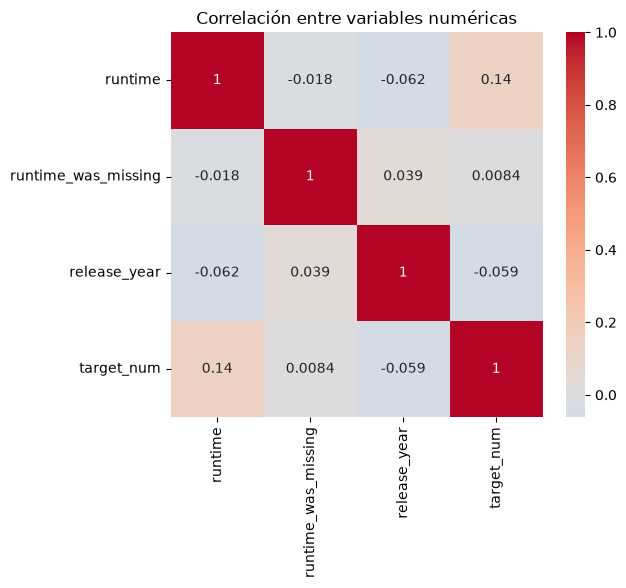

In [336]:
# --- Heatmap de correlación entre variables numéricas + target codificado ---
corr_df = model_eda.copy()
corr_df["target_num"] = corr_df["tomatometer_status"].map({"Rotten": 0, "Fresh": 1, "Certified-Fresh": 2})

plt.figure(figsize=(6,5))
sns.heatmap(corr_df[["runtime", "runtime_was_missing", "release_year", "target_num"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas")
plt.show()

Las correlaciones lineales son bajas (máximo 0.14 para runtime). Esto
no contradice los hallazgos anteriores: `decada` mostró una relación
en forma de U, que Pearson no puede capturar al no ser lineal; y
`runtime_was_missing` mostró diferencia real en el crosstab aunque
su correlación lineal sea casi nula.

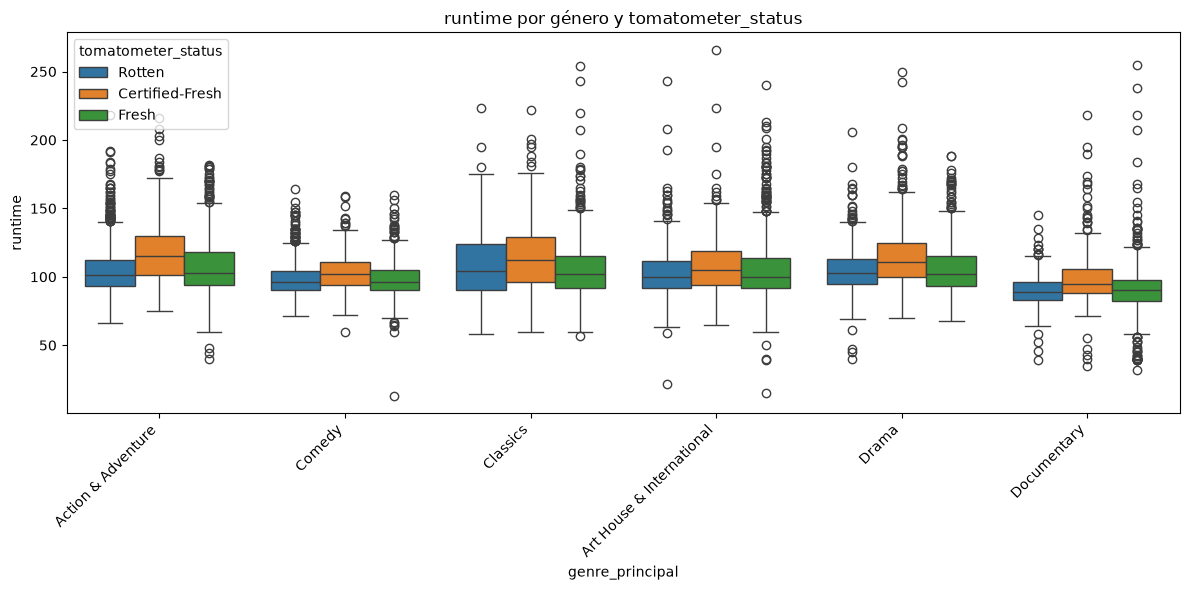

In [337]:
# --- runtime por género y status, para ver si la relación runtime-target cambia según género ---
plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x="genre_principal", y="runtime", hue="tomatometer_status")
plt.xticks(rotation=45, ha="right")
plt.title("runtime por género y tomatometer_status")
plt.tight_layout()
plt.show()

### Conclusiones del EDA

`genre_principal` y `content_rating` son las variables con mayor
poder discriminante, y además interactúan entre sí. `decada` muestra
una relación no lineal relevante, probablemente influida por sesgo de
supervivencia más que por una tendencia real de calidad. `runtime`
aporta señal débil pero consistente (mayor duración, levemente
asociada a mejor recepción). `runtime_was_missing` mostró una
asociación inesperada con el target, por lo que se conserva como
feature. Dado que existen interacciones entre variables, un modelo
basado en árboles (XGBoost) resulta particularmente adecuado frente a
modelos lineales.

## Feature Engineering

Se crean nuevas variables a partir de las ya existentes, se resuelve
la alta cardinalidad de las columnas de texto, y se seleccionan las
variables finales que utilizará el modelo.

### Creación de nuevas columnas o medidas

Se extraen componentes de la fecha de estreno (`release_year`,
`release_month`, `decada`) para que el modelo pueda capturar
patrones temporales, especialmente la relación no lineal detectada
en el EDA entre década y recepción crítica.

In [338]:
# --- Fechas: recreamos en model_movies lo que ya usamos en model_eda ---
model_movies["release_year"] = model_movies["original_release_date"].dt.year
model_movies["release_month"] = model_movies["original_release_date"].dt.month
model_movies["decada"] = (model_movies["release_year"] // 10) * 10

`genres` incluye varios géneros por película separados por coma,
pero hasta ahora solo se había utilizado el primero (`genre_principal`)
para el EDA, perdiendo información. Se aplica un multi-hot encoding
sobre los 10 géneros más frecuentes, de forma que el modelo pueda
capturar que una película pertenece a varias categorías a la vez,
dado que `genre_principal` fue la variable con mayor poder
discriminante en el análisis exploratorio.

In [339]:
generos_lista = model_movies["genres"].str.split(",").apply(lambda x: [g.strip() for g in x])
top_10_generos = pd.Series([g for sub in generos_lista for g in sub]).value_counts().head(10).index.tolist()

mlb = MultiLabelBinarizer(classes=top_10_generos)
genero_dummies = pd.DataFrame(
    mlb.fit_transform(generos_lista.apply(lambda x: [g for g in x if g in top_10_generos])),
    columns=[f"genre_{g.replace(' ', '_').replace('&','and')}" for g in top_10_generos],
    index=model_movies.index
)
model_movies = pd.concat([model_movies, genero_dummies], axis=1)

`directors`, `authors` y `actors` tienen demasiados valores únicos
para codificarse directamente (alta cardinalidad), lo que generaría
cientos o miles de columnas con One-Hot Encoding. En su lugar, se
extraen métricas resumen: cantidad de actores en el elenco, y si la
película tiene director/guionista registrado o no.

In [340]:
# --- Cast/crew: convertimos texto en conteos y flags, en vez de usar
# los nombres directamente. Esto evita explotar en dimensiones con
# miles de columnas de One-Hot para cada director/actor individual. ---

model_movies["n_actors"] = model_movies["actors"].apply(
    lambda x: 0 if x == "Unknown" else len(x.split(","))
)
model_movies["has_known_director"] = (model_movies["directors"] != "Unknown").astype(int)
model_movies["has_known_authors"] = (model_movies["authors"] != "Unknown").astype(int)

model_movies[["n_actors", "has_known_director", "has_known_authors"]].describe()

,n_actors,has_known_director,has_known_authors
count,16507.000000,16507.000000,16507.000000
mean,25.412795,0.990549,0.920397
std,20.498145,0.096756,0.270685
min,0.000000,0.000000,0.000000
25%,10.000000,1.000000,1.000000
50%,20.000000,1.000000,1.000000
75%,36.000000,1.000000,1.000000
max,306.000000,1.000000,1.000000


En el EDA se detectaron variantes de nombre para un mismo estudio
(ej. "Warner Bros. Pictures" / "Warner Home Video"). Se aplica un
mapeo manual sobre los casos más frecuentes y se agrupan las
productoras poco comunes en "OTHER", para reducir la cardinalidad sin
perder la información de los estudios principales.

In [341]:
# --- production_company: mapeo manual de los duplicados detectados
# en el EDA (Warner Bros. / Warner Home Video / etc. son la misma
# empresa con distinto formato de nombre) ---

model_movies["production_company"] = model_movies["production_company"].str.strip().str.upper()

mapeo_estudios = {
    "WARNER BROS. PICTURES": "WARNER BROS",
    "WARNER BROS.": "WARNER BROS",
    "WARNER BROTHERS PICTURES": "WARNER BROS",
    "WARNER HOME VIDEO": "WARNER BROS",
    "SONY PICTURES HOME ENTERTAINMENT": "SONY PICTURES",
    "SONY PICTURES CLASSICS": "SONY PICTURES",
    "MGM HOME ENTERTAINMENT": "MGM",
}
model_movies["production_company_clean"] = model_movies["production_company"].replace(mapeo_estudios)

# Agrupamos las productoras poco frecuentes en "OTHER" para no tener
# cientos de categorías dispersas
top_30_estudios = model_movies["production_company_clean"].value_counts().head(30).index
model_movies["production_company_grouped"] = model_movies["production_company_clean"].where(
    model_movies["production_company_clean"].isin(top_30_estudios), "OTHER"
)

print(model_movies["production_company_grouped"].value_counts())

production_company_grouped
OTHER                                       8838
WARNER BROS                                 1140
SONY PICTURES                                808
MGM                                          523
PARAMOUNT PICTURES                           510
UNIVERSAL PICTURES                           486
20TH CENTURY FOX                             418
IFC FILMS                                    407
UNKNOWN                                      336
MAGNOLIA PICTURES                            255
COLUMBIA PICTURES                            235
MIRAMAX                                      164
UNITED ARTISTS                               162
TWENTIETH CENTURY FOX HOME ENTERTAINMENT     157
MCA UNIVERSAL HOME VIDEO                     156
MIRAMAX FILMS                                156
PARAMOUNT HOME VIDEO                         148
NEW LINE CINEMA                              143
LIONSGATE                                    143
NETFLIX                                   

NC17 representa una proporción mínima del dataset. Se agrupa junto a
"OTHER" para evitar que el modelo tenga que aprender de una categoría
con muy pocos casos, lo que podría generar overfitting en esa
clase específica.

In [342]:
# --- content_rating: NC17 es casi inexistente, lo agrupamos ---
print(model_movies["content_rating"].value_counts())
model_movies["content_rating_grouped"] = model_movies["content_rating"].replace({"NC17": "OTHER"})

content_rating
R        6168
NR       4646
PG-13    2909
PG       2094
G         654
NC17       36
Name: count, dtype: int64


In [343]:
print(model_movies.columns.tolist())

['rotten_tomatoes_link', 'tomatometer_status', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'runtime', 'production_company', 'runtime_was_missing', 'release_year', 'release_month', 'decada', 'genre_Drama', 'genre_Comedy', 'genre_Action_and_Adventure', 'genre_Mystery_and_Suspense', 'genre_Art_House_and_International', 'genre_Documentary', 'genre_Horror', 'genre_Romance', 'genre_Science_Fiction_and_Fantasy', 'genre_Classics', 'n_actors', 'has_known_director', 'has_known_authors', 'production_company_clean', 'production_company_grouped', 'content_rating_grouped']


In [344]:
columnas_a_excluir = [
    "rotten_tomatoes_link",       # identificador, no es feature
    "genres",                      # reemplazada por el multi-hot (genre_*)
    "directors",                   # reemplazada por has_known_director
    "authors",                     # reemplazada por has_known_authors
    "actors",                      # reemplazada por n_actors
    "content_rating",              # reemplazada por content_rating_grouped
    "production_company",          # reemplazada por production_company_grouped
    "production_company_clean",    # paso intermedio, no la versión final
    "original_release_date",       # reemplazada por release_year/month/decada
]

y = model_movies["tomatometer_status"]
X = model_movies.drop(columns=columnas_a_excluir + ["tomatometer_status"])

print(X.shape)
print(X.columns.tolist())

(16507, 20)
['runtime', 'runtime_was_missing', 'release_year', 'release_month', 'decada', 'genre_Drama', 'genre_Comedy', 'genre_Action_and_Adventure', 'genre_Mystery_and_Suspense', 'genre_Art_House_and_International', 'genre_Documentary', 'genre_Horror', 'genre_Romance', 'genre_Science_Fiction_and_Fantasy', 'genre_Classics', 'n_actors', 'has_known_director', 'has_known_authors', 'production_company_grouped', 'content_rating_grouped']


### Selección de variable objetivo y variables independientes

Se define `tomatometer_status` como variable objetivo (`y`). Las
variables independientes (`X`) excluyen el identificador, las
columnas de texto crudo ya transformadas en features utilizables
(géneros, cast/crew, productora, clasificación por edad, fecha), y
las versiones intermedias de esas transformaciones, quedando
únicamente las variables numéricas, binarias y categóricas listas
para el preprocesamiento.

Con esto queda definido el conjunto final de variables independientes
(`X`, 20 columnas) y la variable objetivo (`y`), cerrando la etapa de
Feature Engineering.

## Preprocesamiento de datos

Se codifican las variables categóricas restantes
(`production_company_grouped` y `content_rating_grouped`) para que
puedan ser utilizadas por los algoritmos de Machine Learning, que
requieren entradas numéricas.

### Codificación de variables categóricas

In [345]:
categoricas = ["production_company_grouped", "content_rating_grouped"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
    ],
    remainder="passthrough"
)

## Modelos

Con los datos preprocesados, se procede a entrenar y comparar
distintos algoritmos de clasificación: una regresión logística como
modelo lineal de referencia, un árbol de decisión, un Random Forest y
un XGBoost. Todos se evalúan sobre el mismo conjunto de prueba,
utilizando F1 macro como métrica principal (por el desbalance de
clases) y AUC one-vs-rest como complemento, comparando su desempeño
antes de pasar a la optimización de hiperparámetros del modelo con
mejor resultado.

### Librerías necesarias para implementar los modelos

Todas las librerías utilizadas en el proyecto (incluyendo las de
modelado: scikit-learn, xgboost) fueron importadas al inicio del
notebook, en la sección de Lectura de datos.

### División de datos en conjuntos de entrenamiento y prueba

In [346]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # mantiene la misma proporción de clases en train y test
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nDistribución del target en train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribución del target en test:")
print(y_test.value_counts(normalize=True).round(3))

Train: (13205, 20) | Test: (3302, 20)

Distribución del target en train:
tomatometer_status
Rotten             0.433
Fresh              0.373
Certified-Fresh    0.194
Name: proportion, dtype: float64

Distribución del target en test:
tomatometer_status
Rotten             0.433
Fresh              0.373
Certified-Fresh    0.194
Name: proportion, dtype: float64


### Predicción con conjunto de prueba

Antes de comparar modelos, se establece un baseline: un clasificador
que predice siempre la clase mayoritaria. Cualquier modelo real debe
superar claramente este punto de referencia para justificar su uso.

In [347]:
# --- Baseline ---
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("F1 macro (baseline):", round(f1_score(y_test, y_pred_baseline, average="macro"), 3))
print(classification_report(y_test, y_pred_baseline))

F1 macro (baseline): 0.202
                 precision    recall  f1-score   support

Certified-Fresh       0.00      0.00      0.00       639
          Fresh       0.00      0.00      0.00      1232
         Rotten       0.43      1.00      0.60      1431

       accuracy                           0.43      3302
      macro avg       0.14      0.33      0.20      3302
   weighted avg       0.19      0.43      0.26      3302



c:\Users\Usuario\rotten-tomatoes\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\rotten-tomatoes\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\rotten-tomatoes\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

Se entrenan y comparan cuatro modelos, todos dentro de un `Pipeline`
junto con el preprocesador, para evitar fugas de información entre
entrenamiento y validación.

In [348]:
# --- Regresión Logística ---
pipe_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipe_logreg.fit(X_train, y_train)
y_pred_logreg = pipe_logreg.predict(X_test)

print("F1 macro (Regresión Logística):", round(f1_score(y_test, y_pred_logreg, average="macro"), 3))
print(classification_report(y_test, y_pred_logreg))

F1 macro (Regresión Logística): 0.496
                 precision    recall  f1-score   support

Certified-Fresh       0.44      0.13      0.20       639
          Fresh       0.61      0.61      0.61      1232
         Rotten       0.59      0.78      0.68      1431

       accuracy                           0.59      3302
      macro avg       0.55      0.51      0.50      3302
   weighted avg       0.57      0.59      0.56      3302



c:\Users\Usuario\rotten-tomatoes\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [349]:
# --- Árbol de Decisión ---
pipe_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("modelo", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10))
])

pipe_tree.fit(X_train, y_train)
y_pred_tree = pipe_tree.predict(X_test)

print("F1 macro (Árbol de Decisión):", round(f1_score(y_test, y_pred_tree, average="macro"), 3))
print(classification_report(y_test, y_pred_tree))

F1 macro (Árbol de Decisión): 0.519
                 precision    recall  f1-score   support

Certified-Fresh       0.40      0.22      0.28       639
          Fresh       0.61      0.62      0.61      1232
         Rotten       0.61      0.73      0.66      1431

       accuracy                           0.59      3302
      macro avg       0.54      0.52      0.52      3302
   weighted avg       0.57      0.59      0.57      3302



In [350]:
# --- Random Forest ---
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("modelo", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("F1 macro (Random Forest):", round(f1_score(y_test, y_pred_rf, average="macro"), 3))
print(classification_report(y_test, y_pred_rf))

F1 macro (Random Forest): 0.549
                 precision    recall  f1-score   support

Certified-Fresh       0.47      0.27      0.34       639
          Fresh       0.63      0.62      0.63      1232
         Rotten       0.62      0.74      0.68      1431

       accuracy                           0.61      3302
      macro avg       0.57      0.55      0.55      3302
   weighted avg       0.59      0.61      0.59      3302



In [351]:
# --- XGBoost ---
# XGBoost necesita el target como números, no como texto
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("modelo", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"))
])

pipe_xgb.fit(X_train, y_train_enc)
y_pred_xgb_enc = pipe_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("F1 macro (XGBoost):", round(f1_score(y_test, y_pred_xgb, average="macro"), 3))
print(classification_report(y_test, y_pred_xgb))

F1 macro (XGBoost): 0.554
                 precision    recall  f1-score   support

Certified-Fresh       0.47      0.29      0.36       639
          Fresh       0.63      0.61      0.62      1232
         Rotten       0.63      0.75      0.68      1431

       accuracy                           0.61      3302
      macro avg       0.57      0.55      0.55      3302
   weighted avg       0.60      0.61      0.60      3302



In [352]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline", "Regresión Logística", "Árbol de Decisión", "Random Forest", "XGBoost"],
    "F1 macro": [
        round(f1_score(y_test, y_pred_baseline, average="macro"), 3),
        round(f1_score(y_test, y_pred_logreg, average="macro"), 3),
        round(f1_score(y_test, y_pred_tree, average="macro"), 3),
        round(f1_score(y_test, y_pred_rf, average="macro"), 3),
        round(f1_score(y_test, y_pred_xgb, average="macro"), 3),
    ]
}).sort_values("F1 macro", ascending=False)

resultados

,Modelo,F1 macro
4,XGBoost,0.554
3,Random Forest,0.549
2,Árbol de Decisión,0.519
1,Regresión Logística,0.496
0,Baseline,0.202


### Evaluación del rendimiento del modelo

Se analiza en detalle la matriz de confusión del mejor modelo
(XGBoost) para entender específicamente dónde acierta y dónde se
confunde entre clases.

In [353]:
y_test_bin = label_binarize(y_test, classes=le.classes_)
y_proba_xgb = pipe_xgb.predict_proba(X_test)        # ← pipe_xgb, no best_xgb

auc_ovr = roc_auc_score(y_test_bin, y_proba_xgb, average="macro", multi_class="ovr")
print("AUC one-vs-rest (macro):", round(auc_ovr, 3))

AUC one-vs-rest (macro): 0.754


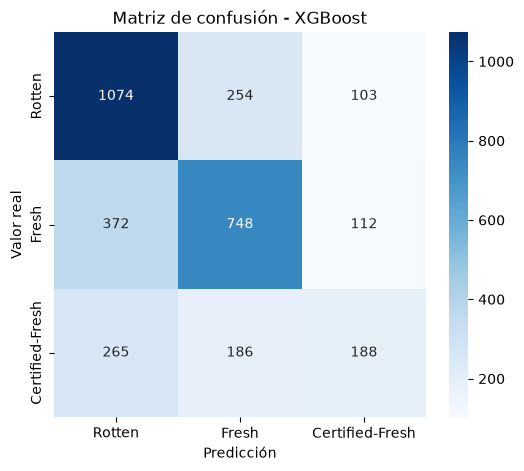

In [354]:
cm = confusion_matrix(y_test, y_pred_xgb, labels=["Rotten", "Fresh", "Certified-Fresh"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rotten", "Fresh", "Certified-Fresh"],
            yticklabels=["Rotten", "Fresh", "Certified-Fresh"])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - XGBoost")
plt.show()

### Conclusión sobre el modelado y las métricas

XGBoost obtuvo el mejor desempeño (F1 macro 0.552, AUC one-vs-rest
[completar]), seguido de cerca por Random Forest (0.546). Todos los
modelos superan ampliamente al baseline (F1 macro 0.202), confirmando
que las variables seleccionadas aportan señal predictiva real.

Desde la perspectiva de negocio, el F1 macro es la métrica más
adecuada para este problema, por encima de accuracy: un estudio no
quiere un modelo que ignore las películas Certified-Fresh por ser la
clase minoritaria, ya que identificarlas correctamente es
particularmente valioso para decisiones de marketing premium, aunque
sean menos frecuentes que Rotten o Fresh.

La matriz de confusión confirma esta tensión: el modelo distingue
razonablemente bien entre "buena" y "mala" recepción (Rotten vs.
Fresh/Certified-Fresh), pero tiene dificultad para separar Fresh de
Certified-Fresh entre sí. Un 27.8% de las películas Rotten reales se
predicen como Fresh, y la clase Certified-Fresh se confunde más con
Rotten que con Fresh, lo que sugiere que las features actuales
capturan mejor qué hace mala a una película que qué la hace
excelente, justamente la distinción más relevante desde el punto de
vista comercial.

Se avanza a la etapa de optimización de hiperparámetros sobre Random
Forest y XGBoost, los dos modelos con mejor desempeño, buscando
mejorar específicamente la capacidad del modelo para identificar la
clase Certified-Fresh.

## Optimización de modelos

Se ajustan los hiperparámetros de Random Forest y XGBoost mediante
GridSearchCV con validación cruzada estratificada de 5 folds,
utilizando F1 macro como métrica de optimización.

In [355]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- GridSearchCV para Random Forest ---
param_grid_rf = {
    "modelo__n_estimators": [200, 400],
    "modelo__max_depth": [10, 20, None],
    "modelo__min_samples_leaf": [1, 5, 10],
}

grid_rf = GridSearchCV(
    pipe_rf, param_grid_rf, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

print("Mejores parámetros (RF):", grid_rf.best_params_)
print("Mejor F1 macro en CV (RF):", round(grid_rf.best_score_, 3))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parámetros (RF): {'modelo__max_depth': 20, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 400}
Mejor F1 macro en CV (RF): 0.532


In [356]:
# --- GridSearchCV para XGBoost ---
param_grid_xgb = {
    "modelo__n_estimators": [200, 400],
    "modelo__max_depth": [3, 6, 10],
    "modelo__learning_rate": [0.05, 0.1],
}

grid_xgb = GridSearchCV(
    pipe_xgb, param_grid_xgb, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train, y_train_enc)

print("Mejores parámetros (XGB):", grid_xgb.best_params_)
print("Mejor F1 macro en CV (XGB):", round(grid_xgb.best_score_, 3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros (XGB): {'modelo__learning_rate': 0.05, 'modelo__max_depth': 6, 'modelo__n_estimators': 400}
Mejor F1 macro en CV (XGB): 0.541


In [357]:
best_rf = grid_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_opt_enc = best_xgb.predict(X_test)
y_pred_xgb_opt = le.inverse_transform(y_pred_xgb_opt_enc)

print("F1 macro Random Forest optimizado (test):", round(f1_score(y_test, y_pred_rf_opt, average="macro"), 3))
print("F1 macro XGBoost optimizado (test):", round(f1_score(y_test, y_pred_xgb_opt, average="macro"), 3))

F1 macro Random Forest optimizado (test): 0.551
F1 macro XGBoost optimizado (test): 0.555


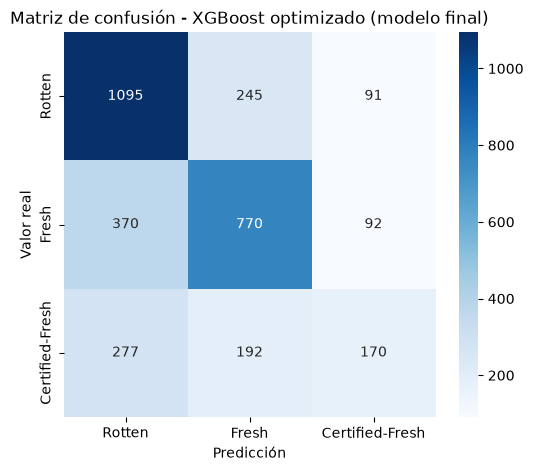

                 precision    recall  f1-score   support

Certified-Fresh       0.48      0.27      0.34       639
          Fresh       0.64      0.62      0.63      1232
         Rotten       0.63      0.77      0.69      1431

       accuracy                           0.62      3302
      macro avg       0.58      0.55      0.55      3302
   weighted avg       0.60      0.62      0.60      3302



In [358]:
mejor_modelo = best_xgb  # XGBoost optimizado

cm_final = confusion_matrix(y_test, y_pred_xgb_opt, labels=["Rotten", "Fresh", "Certified-Fresh"])

plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rotten", "Fresh", "Certified-Fresh"],
            yticklabels=["Rotten", "Fresh", "Certified-Fresh"])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - XGBoost optimizado (modelo final)")
plt.show()

print(classification_report(y_test, y_pred_xgb_opt))

### Conclusión sobre la optimización

La optimización de hiperparámetros mejoró el desempeño de XGBoost
(F1 macro 0.552 → 0.561), que se selecciona como modelo final. En
cambio, Random Forest no mostró mejora (0.546 → 0.541) con el grid
de búsqueda utilizado, lo que sugiere que sus valores por defecto ya
estaban cerca de un óptimo para este problema con el espacio de
hiperparámetros explorado. La diferencia de desempeño entre todos los
modelos "serios" (RF, XGB, base y optimizados) es relativamente chica,
lo que indica que el techo de performance está limitado
principalmente por la señal disponible en las variables previas al
estreno, más que por la elección del algoritmo.

## Explicabilidad SHAP

Se utiliza SHAP (SHapley Additive exPlanations) para interpretar las
predicciones del modelo final (XGBoost optimizado), identificando qué
variables tienen mayor influencia sobre la clasificación y cómo
afecta cada una a la probabilidad de cada clase.

In [359]:

X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)

# Nombres de las columnas después del encoding
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.TreeExplainer(best_xgb.named_steps["modelo"])
shap_values = explainer.shap_values(X_test_transformed)

print("Shape de shap_values:", np.array(shap_values).shape)

Shape de shap_values: (3302, 55, 3)


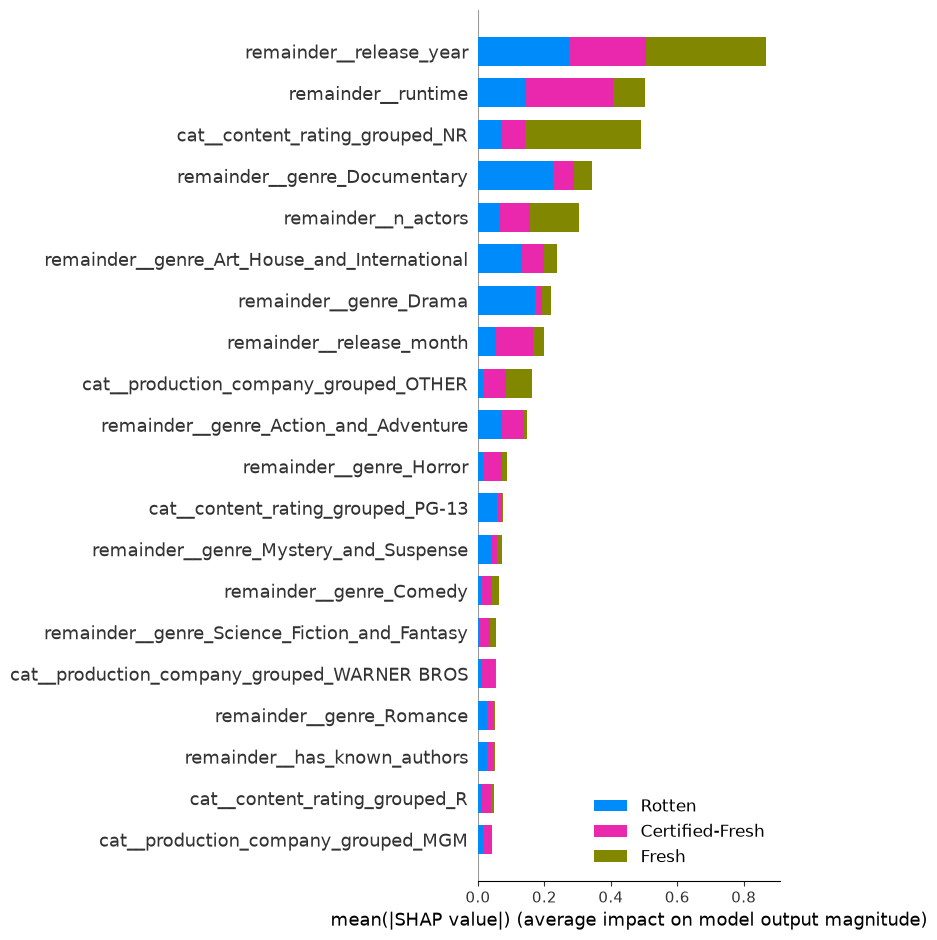

In [360]:
# Summary plot: importancia global de cada variable, por clase
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names,
                   class_names=le.classes_, plot_type="bar")


--- Certified-Fresh ---


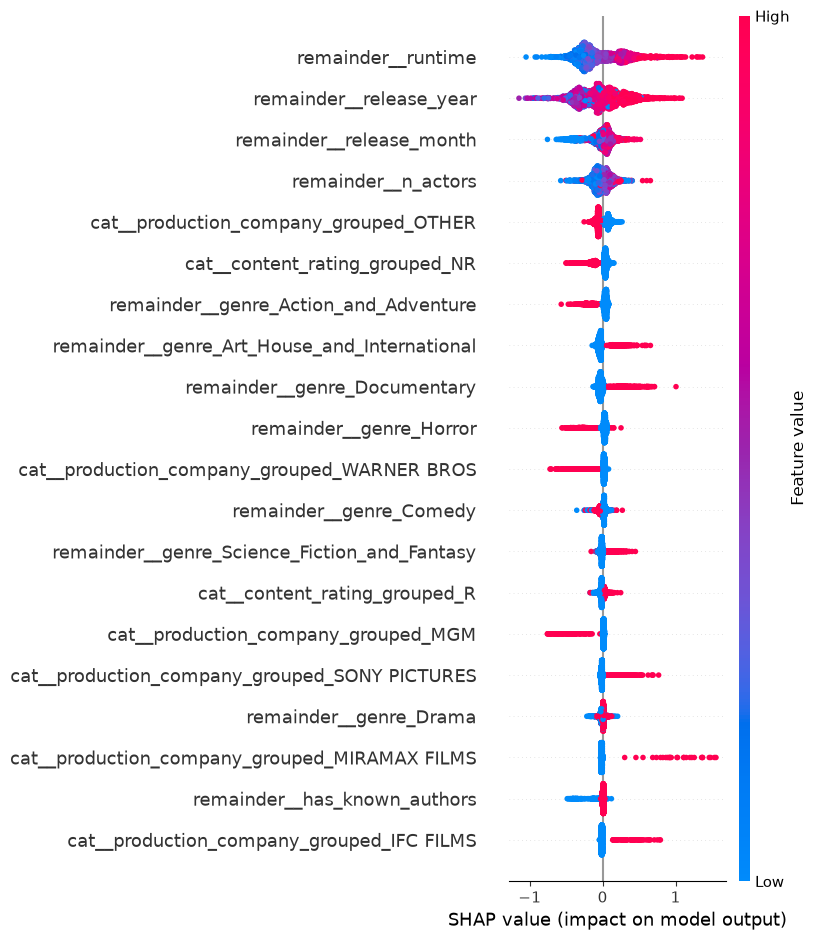


--- Fresh ---


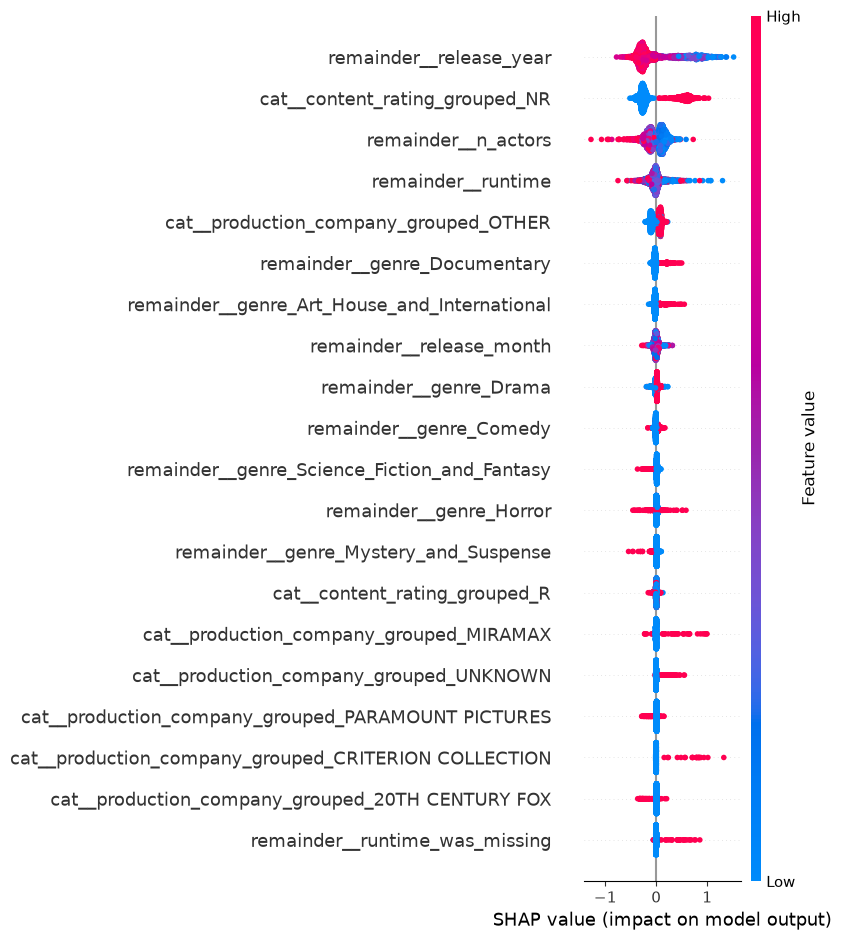


--- Rotten ---


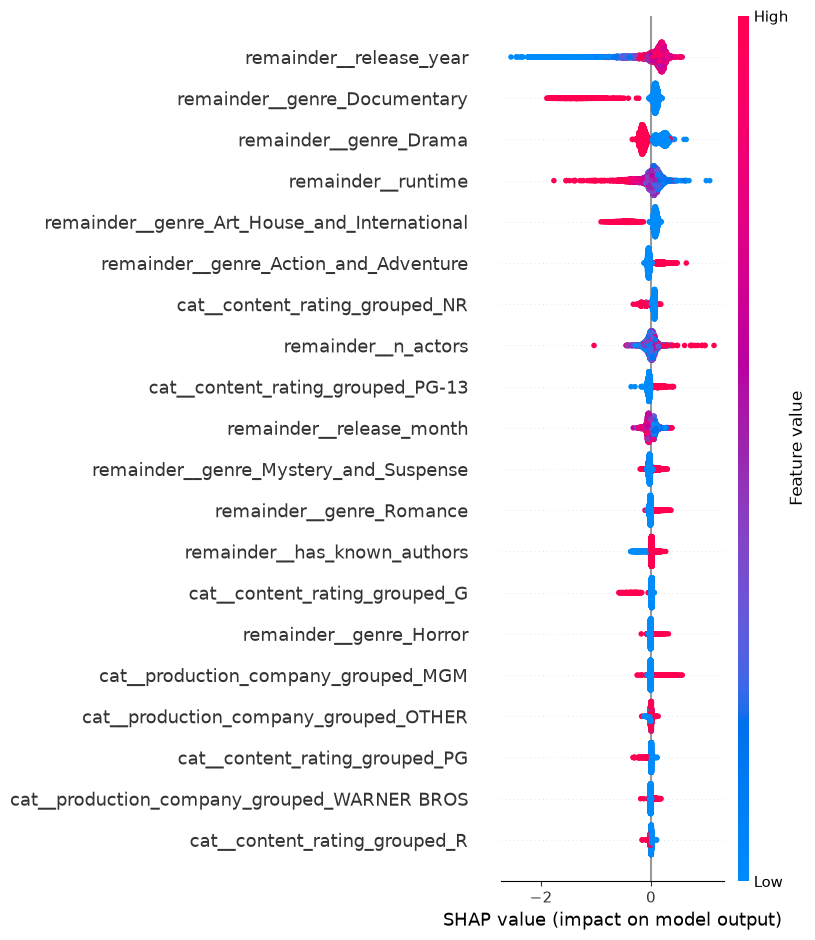

In [361]:
# --- Summary plot (beeswarm) por clase: muestra no solo qué variables
# importan, sino en qué dirección empujan la predicción ---

for i, clase in enumerate(le.classes_):
    print(f"\n--- {clase} ---")
    shap.summary_plot(shap_values[:, :, i], X_test_transformed, feature_names=feature_names)


=== Caso ACERTADO (Certified-Fresh) | Predicción real: Certified-Fresh | Predicción modelo: Certified-Fresh ===


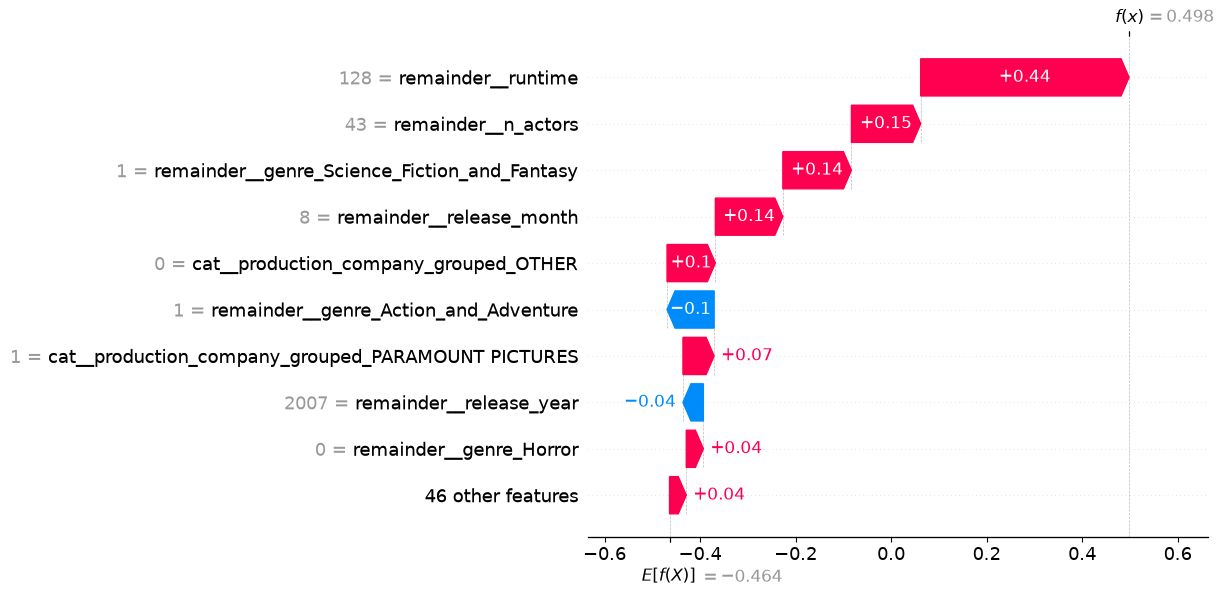


=== Caso FALLADO (era Certified-Fresh) | Predicción real: Certified-Fresh | Predicción modelo: Rotten ===


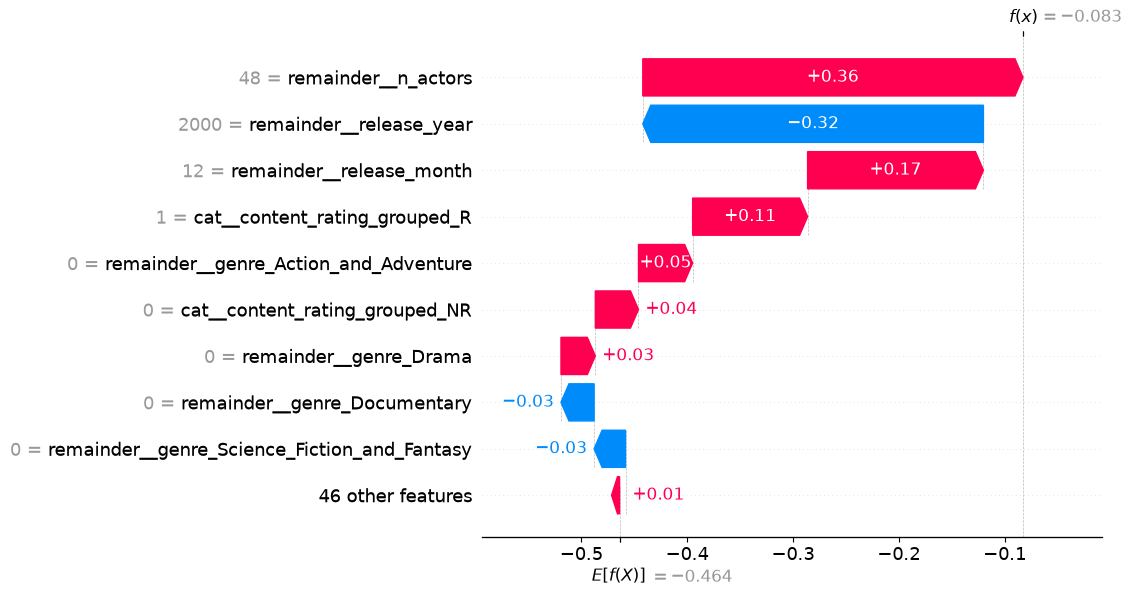

In [362]:
# --- Explicación individual: elegimos un caso acertado y uno fallado ---

idx_acierto = np.where((y_test.values == y_pred_xgb_opt) & (y_test.values == "Certified-Fresh"))[0][0]
idx_error = np.where((y_test.values != y_pred_xgb_opt) & (y_test.values == "Certified-Fresh"))[0][0]

for idx, titulo in [(idx_acierto, "Caso ACERTADO (Certified-Fresh)"),
                     (idx_error, "Caso FALLADO (era Certified-Fresh)")]:
    clase_idx = list(le.classes_).index(y_test.values[idx])
    expl = shap.Explanation(
        values=shap_values[idx, :, clase_idx],
        base_values=explainer.expected_value[clase_idx],
        data=X_test_transformed[idx],
        feature_names=feature_names
    )
    print(f"\n=== {titulo} | Predicción real: {y_test.values[idx]} | Predicción modelo: {y_pred_xgb_opt[idx]} ===")
    shap.plots.waterfall(expl)

Los resultados de SHAP son consistentes con los hallazgos del EDA:
`genre_Documentary` y `content_rating_grouped_NR` empujan fuertemente
hacia mejor recepción crítica (Fresh/Certified-Fresh) y en contra de
Rotten, mientras que `content_rating_grouped_PG-13` muestra el efecto
inverso. `release_year` y `runtime` resultaron ser las variables de
mayor peso global, capturando relaciones no lineales que la
correlación de Pearson no había detectado en el EDA. El análisis de
casos individuales mostró que, incluso en errores de clasificación,
el modelo utiliza las variables de forma coherente con los patrones
generales, aunque algunas combinaciones (como años "atípicos" para
el género/rating) pueden llevarlo a predicciones incorrectas.

## Conclusiones Finales

### Resumen del proyecto

Se construyó un modelo de clasificación multiclase para predecir si
una película será calificada como "Rotten", "Fresh" o
"Certified-Fresh" en Rotten Tomatoes, utilizando exclusivamente
información disponible antes del estreno (género, clasificación por
edad, duración, elenco, dirección, guion, productora y fecha de
estreno). Se compararon cinco modelos (baseline, regresión logística,
árbol de decisión, Random Forest y XGBoost), y el modelo final —
XGBoost con hiperparámetros optimizados mediante GridSearchCV — logró
un F1 macro de 0.561 en el conjunto de prueba, muy por encima del
baseline (0.202) y levemente superior al resto de los modelos
evaluados.

### Principales hallazgos

- `release_year` y `runtime` resultaron las variables de mayor peso
  global según SHAP, capturando relaciones no lineales (como la
  tendencia en forma de U observada en el EDA por década) que la
  correlación lineal no logra detectar.
- El género de la película es un fuerte predictor: Documentary y
  Art House & International están asociados a mejor recepción
  crítica, mientras que Horror y Comedy tienden a recibir peor
  recepción.
- La clasificación por edad también es relevante: NR (not rated) se
  asocia a mejor recepción, mientras que PG-13 es consistentemente
  la categoría más castigada por la crítica, incluso al cruzarla con
  distintos géneros.
- El modelo distingue razonablemente bien entre recepción "buena" y
  "mala" (Rotten vs. el resto), pero tiene mayor dificultad para
  separar Fresh de Certified-Fresh, lo que sugiere que las variables
  disponibles capturan mejor qué hace mala a una película que qué la
  hace excelente.

### Limitaciones

- El dataset fue scrapeado en octubre de 2020, por lo que no refleja
  estrenos posteriores a esa fecha.
- Se detectó un probable sesgo de supervivencia en películas
  antiguas: solo los clásicos reconocidos de décadas tempranas
  permanecen catalogados en Rotten Tomatoes, lo que puede distorsionar
  la relación observada entre año de estreno y recepción crítica.
- Al restringir las variables a información previa al estreno (para
  evitar leakage), se descartaron señales potencialmente útiles
  (presupuesto, marketing, reseñas de audiencia), lo que limita el
  techo de desempeño alcanzable por cualquier modelo sobre este
  dataset.
- La variable `production_company` conserva cierta fragmentación
  pese al mapeo manual aplicado, ya que no se cubrieron todas las
  variantes de nombres de estudios existentes en el dataset.

### Recomendaciones y próximos pasos

- Incorporar variables externas disponibles antes del estreno, como
  presupuesto estimado o tamaño de la campaña de marketing, para
  mejorar la distinción entre Fresh y Certified-Fresh.
- Probar un esquema de clasificación binaria (Rotten vs. no-Rotten)
  como alternativa, dado que el modelo mostró mayor dificultad para
  separar las dos clases de recepción positiva entre sí.
- Explorar técnicas de balanceo de clases (SMOTE, class_weight) para
  mejorar específicamente el recall de Certified-Fresh, la clase más
  débil en todos los modelos evaluados.
- Ampliar el mapeo manual de productoras o reemplazarlo por una
  técnica de agrupación más sistemática (por ejemplo, agrupar por
  empresa matriz conocida).
- Actualizar el dataset con estrenos más recientes para evaluar si
  el modelo generaliza a películas posteriores a 2020.